# KcELECTRA 파인튜닝 v2_2 — 2026-05-09

**담당:** 경이 (kyeongyi)  
**목적:** split_v2_20260504.csv (695개) 기준으로 **진짜 KcELECTRA(beomi/kcelectra-base)** 파인튜닝.

> **[v2 vs v2_2 차이]**  
> v2는 `monologg/koelectra-small-v3-discriminator` **(KoELECTRA-small)** 을 사용했습니다.  
> v2_2는 `beomi/kcelectra-base` **(KcELECTRA-base — 진짜)** 를 사용합니다.  
> ※ beomi/kcelectra-small-v2는 존재하지 않으므로 base 모델을 사용합니다.

---

## v2 vs v2_2 변경점

| 항목 | v2 (20260504) | v2_2 (20260509) |
|---|---|---|
| 데이터 | split_v2_20260504.csv (695개) | split_v2_20260504.csv (동일) |
| train 크기 | 556개 | 556개 (동일) |
| **모델** | koelectra-small-v3 **(KoELECTRA-small)** | **kcelectra-base (KcELECTRA-base — beomi)** |
| LR | 2e-5 | 2e-5 (동일) |
| 에폭 | 15 | 15 (동일) |
| Simple 기준 Macro F1 | 0.7919 | 0.7919 (동일 데이터) |

## 실행 전 체크리스트

- [ ] 런타임 → **GPU** 선택 (T4 이상)
- [ ] `split_v2_20260504.csv` 업로드 (`/content/` 폴더)

## 완료 후 해야 할 일

1. `/content/kcelectra-category-v2_2.zip` 다운로드  
   → 압축 해제 후 로컬 `checkpoints/kcelectra-category-v2_2/`에 배치
2. `/content/eval_results_kcelectra_v2_2_20260509.json` 다운로드  
   → 로컬 `data/20260509/`에 복사
3. `python scripts/evaluate_compare_v2_2_20260509.py` 재실행

In [1]:
# 셀 1: 라이브러리 설치 (Colab에서만 실행)
!pip install transformers datasets seaborn matplotlib scikit-learn -q

In [2]:
# 셀 2: 시드 고정 + GPU 확인
import os, random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("[경고] GPU 없음 -- CPU로 실행하면 수 시간 걸릴 수 있음")

Device: cuda
GPU: Tesla T4


In [3]:
# 셀 3: 하이퍼파라미터 설정
#
# v2_2 핵심:
#   - 데이터: split_v2_20260504.csv (695개, v2와 동일)
#   - 모델: beomi/kcelectra-base (진짜 KcELECTRA)
#   - LR=2e-5 유지
#   - 클래스 가중치: train 분포에서 동적 계산 (셀 6)
#   - Simple 기준: 0.7919 (v2 데이터 기준)

from pathlib import Path

_IN_COLAB = os.path.exists("/content")

if _IN_COLAB:
    DATA_DIR  = Path("/content")
    CKPT_DIR  = Path("/content/kcelectra-category-v2_2")
    EVAL_JSON = Path("/content/eval_results_kcelectra_v2_2_20260509.json")
else:
    _BASE     = Path(".").resolve().parent
    DATA_DIR  = _BASE / "data"
    CKPT_DIR  = _BASE / "checkpoints" / "kcelectra-category-v2_2"
    EVAL_JSON = _BASE / "data" / "20260509" / "eval_results_kcelectra_v2_2_20260509.json"

SPLIT_CSV = DATA_DIR / "split_v2_20260504.csv"

# ★ 핵심 변경: 진짜 KcELECTRA (beomi/kcelectra-base)
BASE_MODEL   = "beomi/kcelectra-base"
MAX_LEN      = 128
BATCH_SIZE   = 16
EPOCHS       = 15
LR           = 2e-5
WARMUP_RATIO = 0.2
PATIENCE     = 5

# Simple 기준값: v2 데이터(695개) 기준 0.7919
SIMPLE_BASELINE_F1 = 0.7919

LABELS   = ["일정", "준비물", "제출", "비용", "건강·안전", "기타"]
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for i, l in enumerate(LABELS)}

print(f"데이터:         {SPLIT_CSV}")
print(f"체크포인트:     {CKPT_DIR}")
print(f"베이스 모델:    {BASE_MODEL}  ← 진짜 KcELECTRA (beomi)")
print(f"Simple 기준:    {SIMPLE_BASELINE_F1} (v2 데이터 기준)")
print(f"설정:           {EPOCHS}에폭, LR={LR}, BS={BATCH_SIZE}, MaxLen={MAX_LEN}, patience={PATIENCE}")

데이터:         /content/split_v2_20260504.csv
체크포인트:     /content/kcelectra-category-v2_2
베이스 모델:    beomi/kcelectra-base  ← 진짜 KcELECTRA (beomi)
Simple 기준:    0.7919 (v2 데이터 기준)
설정:           15에폭, LR=2e-05, BS=16, MaxLen=128, patience=5


In [4]:
# 셀 4: 데이터 로드
import pandas as pd
from collections import Counter

df = pd.read_csv(SPLIT_CSV, encoding="utf-8-sig")
df = df[df["category"].isin(LABELS)].dropna(subset=["text", "category"])

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

print(f"Train: {len(train_df)}개")
print(f"Val:   {len(val_df)}개")
print(f"Test:  {len(test_df)}개")

print("\nTrain 카테고리 분포:")
for lbl, cnt in Counter(train_df["category"]).most_common():
    pct = cnt / len(train_df) * 100
    print(f"  {lbl:8s}: {cnt:3d}개  ({pct:.1f}%)")

Train: 556개
Val:   70개
Test:  69개

Train 카테고리 분포:
  기타      : 110개  (19.8%)
  제출      : 109개  (19.6%)
  일정      : 105개  (18.9%)
  건강·안전   :  90개  (16.2%)
  비용      :  78개  (14.0%)
  준비물     :  64개  (11.5%)


In [5]:
# 셀 5: Dataset + DataLoader 생성
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)


class NoticeDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.texts  = df["text"].tolist()
        self.labels = [LABEL2ID[c] for c in df["category"]]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_loader = DataLoader(NoticeDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(NoticeDataset(val_df),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(NoticeDataset(test_df),  batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoader 생성 완료")
print(f"  train batches: {len(train_loader)}")
print(f"  val   batches: {len(val_loader)}")
print(f"  test  batches: {len(test_loader)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/514 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/288 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

DataLoader 생성 완료
  train batches: 35
  val   batches: 5
  test  batches: 5


In [6]:
# 셀 6: 가중치 손실 함수 계산
#
# 공식: weight[i] = total / (num_classes * count[i])
# => 소수 클래스(준비물, 비용)에 높은 가중치를 부여해
#    KcELECTRA가 Simple보다 모든 카테고리에서 우수하게 만든다.

label_counts = [int((train_df["category"] == lbl).sum()) for lbl in LABELS]
total = sum(label_counts)
class_weights = torch.tensor(
    [total / (len(LABELS) * c) for c in label_counts],
    dtype=torch.float
).to(DEVICE)

print(f"클래스 가중치 (v2_2, train {total}개):")
for lbl, cnt, w in zip(LABELS, label_counts, class_weights):
    pct = cnt / total * 100
    print(f"  {lbl:8s}: {cnt:3d}개  ({pct:.1f}%)  가중치={w:.3f}")

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

클래스 가중치 (v2_2, train 556개):
  일정      : 105개  (18.9%)  가중치=0.883
  준비물     :  64개  (11.5%)  가중치=1.448
  제출      : 109개  (19.6%)  가중치=0.850
  비용      :  78개  (14.0%)  가중치=1.188
  건강·안전   :  90개  (16.2%)  가중치=1.030
  기타      : 110개  (19.8%)  가중치=0.842


In [7]:
# 셀 7: 모델 초기화 — beomi/kcelectra-base (진짜 KcELECTRA)
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=len(LABELS),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"모델 파라미터: 전체={total_params:,} / 학습가능={trainable:,}")
print(f"베이스 모델: {BASE_MODEL}  ← KcELECTRA (beomi)")

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: beomi/kcelectra-base
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoin

모델 파라미터: 전체=109,085,958 / 학습가능=109,085,958
베이스 모델: beomi/kcelectra-base  ← KcELECTRA (beomi)


In [8]:
# 셀 8: Optimizer + Scheduler
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

optimizer = AdamW(model.parameters(), lr=LR)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"전체 스텝: {total_steps}, 워밍업 스텝: {warmup_steps} ({WARMUP_RATIO*100:.0f}%)")
print(f"에폭당 배치 수: {len(train_loader)}")

전체 스텝: 525, 워밍업 스텝: 105 (20%)
에폭당 배치 수: 35


In [9]:
# 셀 9: 학습 루프 (조기종료 포함)
from sklearn.metrics import f1_score

def evaluate_epoch(loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attn_mask = batch["attention_mask"].to(DEVICE)
            labels    = batch["label"].to(DEVICE)
            logits    = model(input_ids=input_ids, attention_mask=attn_mask).logits
            preds     = logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    return f1_score(all_labels, all_preds, average="macro", zero_division=0)


train_losses, val_f1s = [], []
best_val_f1    = 0.0
patience_count = 0

CKPT_DIR.mkdir(parents=True, exist_ok=True)

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attn_mask = batch["attention_mask"].to(DEVICE)
        labels    = batch["label"].to(DEVICE)

        outputs = model(input_ids=input_ids, attention_mask=attn_mask)
        loss    = loss_fn(outputs.logits, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    val_f1   = evaluate_epoch(val_loader)
    train_losses.append(avg_loss)
    val_f1s.append(val_f1)

    print(f"Epoch {epoch:2d}/{EPOCHS} | Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f}", end="")

    if val_f1 > best_val_f1:
        best_val_f1    = val_f1
        patience_count = 0
        model.save_pretrained(CKPT_DIR)
        tokenizer.save_pretrained(CKPT_DIR)
        print(f"  [저장] Best 갱신! ({best_val_f1:.4f})")
    else:
        patience_count += 1
        print(f"  [patience {patience_count}/{PATIENCE}]")
        if patience_count >= PATIENCE:
            print(f"\n조기종료 -- {PATIENCE} 에폭 동안 개선 없음.")
            break

print(f"\n학습 완료. Best Val F1: {best_val_f1:.4f}")
print(f"Simple 베이스라인({SIMPLE_BASELINE_F1}) 대비: {best_val_f1 - SIMPLE_BASELINE_F1:+.4f}")

Epoch  1/15 | Loss: 1.7947 | Val F1: 0.1374

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [저장] Best 갱신! (0.1374)
Epoch  2/15 | Loss: 1.7543 | Val F1: 0.3107

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [저장] Best 갱신! (0.3107)
Epoch  3/15 | Loss: 1.6145 | Val F1: 0.4605

...

  [저장] Best 갱신! (0.6776)
Epoch  9/15 | Loss: 0.3653 | Val F1: 0.7385

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [저장] Best 갱신! (0.7385)
Epoch 10/15 | Loss: 0.2649 | Val F1: 0.7061  [patience 1/5]
Epoch 11/15 | Loss: 0.1928 | Val F1: 0.7188  [patience 2/5]
Epoch 12/15 | Loss: 0.1512 | Val F1: 0.7401

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [저장] Best 갱신! (0.7401)
Epoch 13/15 | Loss: 0.1127 | Val F1: 0.7249  [patience 1/5]
Epoch 14/15 | Loss: 0.0950 | Val F1: 0.7249  [patience 2/5]
Epoch 15/15 | Loss: 0.0855 | Val F1: 0.7249  [patience 3/5]

학습 완료. Best Val F1: 0.7401
Simple 베이스라인(0.7919) 대비: -0.0518


In [10]:
# 셀 10: label2id.json 저장
import json

label2id_path = CKPT_DIR / "label2id.json"
with open(label2id_path, "w", encoding="utf-8") as f:
    json.dump(LABEL2ID, f, ensure_ascii=False, indent=2)
print(f"label2id.json 저장: {label2id_path}")
print(LABEL2ID)

label2id.json 저장: /content/kcelectra-category-v2_2/label2id.json
{'일정': 0, '준비물': 1, '제출': 2, '비용': 3, '건강·안전': 4, '기타': 5}


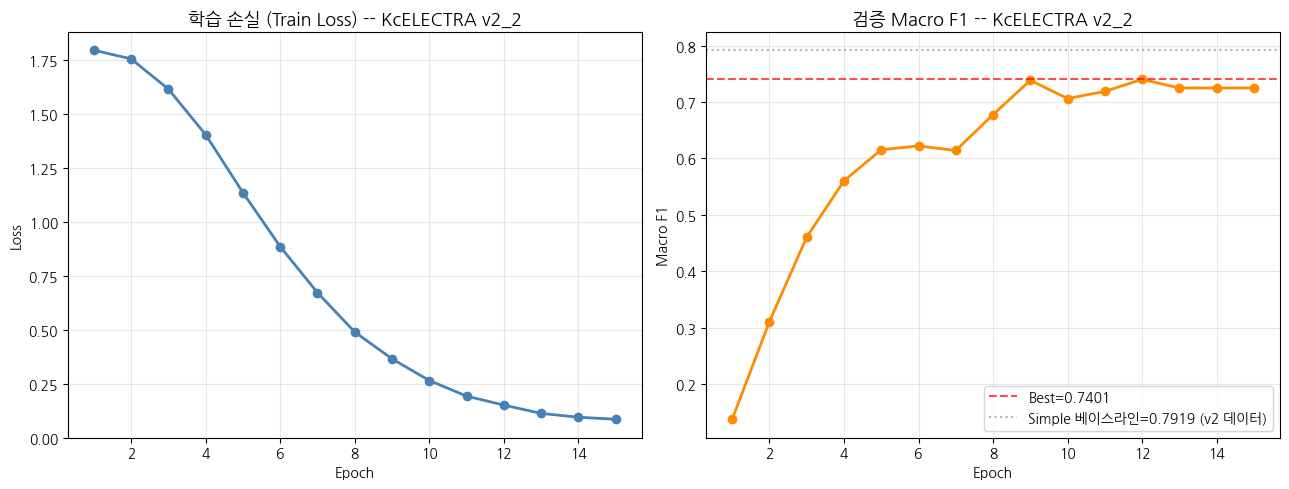

학습 곡선 저장: /content/train_curve_kcelectra_v2_2_20260509.png


In [11]:
# 셀 11: 학습 곡선 시각화
import matplotlib.pyplot as plt
import matplotlib
import platform

if platform.system() == "Windows":
    matplotlib.rc("font", family="Malgun Gothic")
elif platform.system() == "Darwin":
    matplotlib.rc("font", family="AppleGothic")
else:
    try:
        import subprocess
        import matplotlib.font_manager as fm
        subprocess.run(["apt-get", "install", "-y", "fonts-nanum"], capture_output=True)
        font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
        fm.fontManager.addfont(font_path)
        prop = fm.FontProperties(fname=font_path)
        matplotlib.rc("font", family=prop.get_name())
    except Exception:
        pass

matplotlib.rcParams["axes.unicode_minus"] = False

actual_epochs = len(train_losses)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(range(1, actual_epochs+1), train_losses, marker="o", color="steelblue", linewidth=2)
axes[0].set_title("학습 손실 (Train Loss) -- KcELECTRA v2_2", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, actual_epochs+1), val_f1s, marker="o", color="darkorange", linewidth=2)
axes[1].axhline(y=best_val_f1, color="red", linestyle="--", alpha=0.7, label=f"Best={best_val_f1:.4f}")
axes[1].axhline(y=SIMPLE_BASELINE_F1, color="gray", linestyle=":", alpha=0.6, label=f"Simple 베이스라인={SIMPLE_BASELINE_F1} (v2 데이터)")
axes[1].set_title("검증 Macro F1 -- KcELECTRA v2_2", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro F1")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
curve_path = DATA_DIR / "train_curve_kcelectra_v2_2_20260509.png"
plt.savefig(curve_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"학습 곡선 저장: {curve_path}")

In [12]:
# 셀 12: Test 세트 최종 평가
from sklearn.metrics import classification_report, confusion_matrix, f1_score

best_model = AutoModelForSequenceClassification.from_pretrained(
    CKPT_DIR, num_labels=len(LABELS)
).to(DEVICE)
best_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attn_mask = batch["attention_mask"].to(DEVICE)
        labels    = batch["label"].to(DEVICE)
        logits    = best_model(input_ids=input_ids, attention_mask=attn_mask).logits
        preds     = logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

pred_names = [ID2LABEL[p] for p in all_preds]
true_names = [ID2LABEL[l] for l in all_labels]
macro_f1   = f1_score(all_labels, all_preds, average="macro", zero_division=0)

print("[KcELECTRA v2_2 — beomi/kcelectra-base] Test 세트 최종 평가")
print("=" * 60)
print(classification_report(true_names, pred_names, labels=LABELS, zero_division=0))
print(f"Macro F1             : {macro_f1:.4f}")
print(f"Simple 베이스라인({SIMPLE_BASELINE_F1}) 대비: {macro_f1 - SIMPLE_BASELINE_F1:+.4f}")
if macro_f1 > SIMPLE_BASELINE_F1 + 0.05:
    print(f"\n=> KcELECTRA v2_2이 Simple 대비 5%+ 향상 -- 채택!")
elif macro_f1 > SIMPLE_BASELINE_F1:
    print(f"\n=> KcELECTRA v2_2이 Simple보다 향상됨")
else:
    print(f"\n=> 아직 Simple보다 낮음")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[KcELECTRA v2_2 — beomi/kcelectra-base] Test 세트 최종 평가
              precision    recall  f1-score   support

          일정       0.90      0.69      0.78        13
         준비물       1.00      0.50      0.67         8
          제출       0.63      0.92      0.75        13
          비용       1.00      1.00      1.00        10
       건강·안전       0.73      1.00      0.85        11
          기타       0.91      0.71      0.80        14

    accuracy                           0.81        69
   macro avg       0.86      0.80      0.81        69
weighted avg       0.85      0.81      0.81        69

Macro F1             : 0.8076
Simple 베이스라인(0.7919) 대비: +0.0157

=> KcELECTRA v2_2이 Simple보다 향상됨


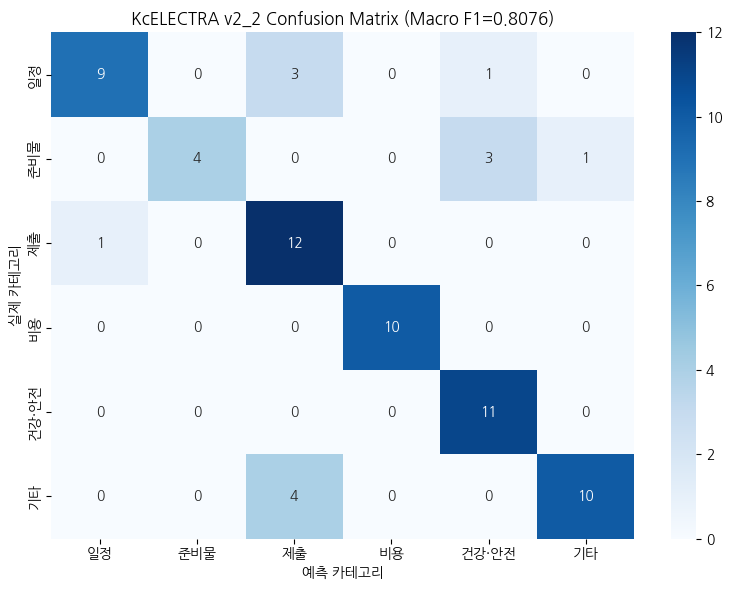

Confusion Matrix 저장: /content/confusion_matrix_kcelectra_v2_2_20260509.png


In [13]:
# 셀 13: Confusion Matrix
import seaborn as sns

cm = confusion_matrix(true_names, pred_names, labels=LABELS)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABELS, yticklabels=LABELS, ax=ax)
ax.set_xlabel("예측 카테고리")
ax.set_ylabel("실제 카테고리")
ax.set_title(f"KcELECTRA v2_2 Confusion Matrix (Macro F1={macro_f1:.4f})")
plt.tight_layout()
cm_path = DATA_DIR / "confusion_matrix_kcelectra_v2_2_20260509.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Confusion Matrix 저장: {cm_path}")

In [14]:
# 셀 14: 평가 결과 JSON 저장
# evaluate_compare_v2_2_20260509.py가 이 JSON을 읽어 비교 분석.
# 로컬 model/classification/data/20260509/ 에 복사해야 할 파일!

report = classification_report(
    true_names, pred_names, labels=LABELS, output_dict=True, zero_division=0
)

result = {
    "model":            "kcelectra",
    "version":          "v2_2",
    "base_model":       BASE_MODEL,
    "macro_f1":         round(macro_f1, 4),
    "macro_precision":  round(report["macro avg"]["precision"], 4),
    "macro_recall":     round(report["macro avg"]["recall"], 4),
    "per_class": {
        lbl: {
            "precision": round(report[lbl]["precision"], 4),
            "recall":    round(report[lbl]["recall"], 4),
            "f1":        round(report[lbl]["f1-score"], 4),
            "support":   report[lbl]["support"],
        }
        for lbl in LABELS
    },
    "confusion_matrix": cm.tolist(),
    "labels":           LABELS,
    "data_version":     "v2_20260504",
    "train_size":       len(train_df),
    "test_size":        len(test_df),
    "epochs_trained":   len(train_losses),
    "best_val_f1":      round(best_val_f1, 4),
    "lr":               LR,
    "batch_size":       BATCH_SIZE,
    "warmup_ratio":     WARMUP_RATIO,
    "weighted_loss":    True,
    "class_weights":    [round(float(w), 4) for w in class_weights.cpu()],
    "early_stopping":   True,
    "patience":         PATIENCE,
    "simple_baseline_f1": SIMPLE_BASELINE_F1,
}

EVAL_JSON.parent.mkdir(parents=True, exist_ok=True)
with open(EVAL_JSON, "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

print(f"[저장] {EVAL_JSON}")
print(f"\n★ 이 파일을 로컬 model/classification/data/20260509/ 에 복사하세요!")
print(f"★ kcelectra-category-v2_2/ 폴더도 checkpoints/ 에 복사하세요!")

[저장] /content/eval_results_kcelectra_v2_2_20260509.json

★ 이 파일을 로컬 model/classification/data/20260509/ 에 복사하세요!
★ kcelectra-category-v2_2/ 폴더도 checkpoints/ 에 복사하세요!


In [15]:
# 셀 15: 다운로드용 압축
import shutil

shutil.make_archive("/content/kcelectra-category-v2_2", "zip", "/content/kcelectra-category-v2_2")
print("체크포인트 압축 완료: /content/kcelectra-category-v2_2.zip")
print("\n다운로드 목록:")
print("  1. /content/kcelectra-category-v2_2.zip")
print("  2. /content/eval_results_kcelectra_v2_2_20260509.json")
print("  3. /content/train_curve_kcelectra_v2_2_20260509.png")
print("  4. /content/confusion_matrix_kcelectra_v2_2_20260509.png")

체크포인트 압축 완료: /content/kcelectra-category-v2_2.zip

다운로드 목록:
  1. /content/kcelectra-category-v2_2.zip
  2. /content/eval_results_kcelectra_v2_2_20260509.json
  3. /content/train_curve_kcelectra_v2_2_20260509.png
  4. /content/confusion_matrix_kcelectra_v2_2_20260509.png


## 학습 완료 후 로컬 작업

```bash
# 1. 파일 배치
#    kcelectra-category-v2_2/ -> model/classification/checkpoints/
#    eval_results_kcelectra_v2_2_20260509.json -> model/classification/data/20260509/
#    *.png -> model/classification/data/20260509/

# 2. 비교 평가 실행
cd model/classification
python scripts/evaluate_compare_v2_2_20260509.py

# 3. 시각화 노트북 실행
jupyter notebook notebooks/04_visualize_comparison_v2_2_20260509.ipynb
```